# 实战 Case 3: 文本挖掘与情感分析 (NLP Sentiment Analysis) 🗣️

## 1. 项目背景
*   **目标**: 让机器读懂中文评论，判断用户是"夸你"还是"骂你" (Binary Classification)。
*   **核心挑战**:
    1.  **非结构化数据**: 计算机只认识数字，不认识汉字。
    2.  **中文分词**: 英文有空格分隔，中文必须用 `jieba` 切词。
    3.  **高维稀疏**: 几万个不同的词汇，会导致特征矩阵巨大 (Curse of Dimensionality)。
*   **适用算法**: Naive Bayes (基线), Logistic Regression (最强), SVM, LSTM/BERT (进阶)。

## 2. 导入库 (Libraries Import)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba # 🇨🇳 结巴分词 (Chinese Word Segmentation)
from wordcloud import WordCloud # ☁️ 词云
import warnings
import platform

# 1. 忽略警告
warnings.filterwarnings('ignore')

# 2. 绘图设置
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

# 3. 解决中文乱码
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:
    plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("✅ NLP Environment Setup Complete! (jieba + wordcloud)")

✅ NLP Environment Setup Complete! (jieba + wordcloud)


## 3. NLP 标准分析流程 (SOP) 🛠️
*这也是面试时必答的 Workflow:*

1.  **文本预处理 (Preprocessing)**:
    *   去除特殊符号 (Regex)
    *   去除停用词 (Stopwords Removal): 如"的", "了", "是"这些无意义词。
2.  **分词 (Tokenization)**:
    *   英文自带空格分词，中文必须用 `jieba.cut` 将句子切分成词语。
3.  **特征向量化 (Feature Extraction)**:
    *   **Bag of Words (BoW)**: 词频统计。
    *   **TF-IDF**: 衡量词语的重要性 (Term Frequency-Inverse Document Frequency)。**这是最常用的 Baseline**。
    *   **Word2Vec**: 将词转换为稠密向量 (Dense Vector)，捕捉语义相似性。
4.  **建模 (Modeling)**:
    *   **Naive Bayes**: 文本分类基线，速度极快。
    *   **Logistic Regression**: 简单且鲁棒性强，也是极强的 Baseline。
    *   **XGBoost / LightGBM**: 提升树模型，通常效果最好。
5.  **主题挖掘 (Topic Modeling)**:
    *   **LDA**: 发现文本中隐藏的主题 (Topic 1: 物流慢, Topic 2: 客服态度差)。

In [16]:
# ⛽️ 函数加油站 (Functions Gas Station)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation
import re

def get_stopwords():
    """
    获得中文停用词表
    """
    stopwords = [
        '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个', '上', '也', '很', '到', '说', '要', '去', '你', 
        '会', '着', '没有', '看', '好', '自己', '这', '那', '有', '个', '之', '为', '与', '及', '等', '或', '把', '被', '让', '啊', 
        '嘛', '呢', '吧', '啦', '呀', '哦', '嗯', '呃'
    ]
    # 实际项目中，你可以加载停用词文件: stopwords = [line.strip() for line in open('stopwords.txt', encoding='utf-8').readlines()]
    return set(stopwords)

def preprocess_text(text):
    """
    文本清洗 + 分词 + 去停用词
    """
    if pd.isnull(text):
        return ""
    
    # 1. 清洗: 只保留中文、英文、数字
    # text = re.sub(r"[^\u4e00-\u9fa5a-zA-Z0-9]", "", str(text))
    text = str(text)
    
    # 2. 分词
    words = jieba.cut(text)
    
    # 3. 去停用词
    stopwords = get_stopwords()
    result = [w for w in words if w not in stopwords and len(w) > 1] # 仅保留长度>1的词
    
    return " ".join(result) # 返回空格分隔的字符串 (sklearn需要这样的格式)

print("✅ Function Station Ready: Text Processing & Models Loaded!")

✅ Function Station Ready: Text Processing & Models Loaded!


In [17]:
# 4. 生成模拟电商评论数据 (Simulated E-commerce Reviews) 📦
# 真实场景中，你会从 SQL (Hive) 读取 df = pd.read_sql("SELECT comment, rating FROM app.dwd_comment_log LIMIT 10000")

positive_corpus = [
    "物流超级快，第二天就到了！",
    "客服小姐姐态度很好，非常有耐心，解决了我的问题。",
    "质量不错，手感很好，物超所值。",
    "包装很严实，没有破损，好评！",
    "非常满意的一次购物，下次还会再来。",
    "衣服版型很好，穿起来很显瘦。",
    "虽然中间出了点小插曲，但客服很快处理了，满意。",
    "正品，和专柜一样，价格还便宜。",
    "安装师傅很专业，服务到位。",
    "给爸妈买的，他们很喜欢，操作简单。"
]

negative_corpus = [
    "物流太慢了，等了一个星期才发货。",
    "客服态度极差，问两句就不耐烦了，差评！",
    "质量太差了，刚收到就坏了，简直是垃圾。",
    "包装破破烂烂的，里面的东西都漏出来了。",
    "实物和图片严重不符，欺骗消费者。",
    "衣服起球严重，穿了一次就扔了。",
    "退款拖了一周都没处理，这效率也是醉了。",
    "千万别买，这就是个坑，智商税。",
    "联系不上客服，这就是所谓的售后？",
    "尺寸根本不对，大了很多，没办法穿。"
]

# 构建数据集 (各复制50次以模拟数据量)
data = []
for _ in range(50):
    for text in positive_corpus:
        data.append({'comment': text, 'sentiment': 1}) # 1: 正向/好评
    for text in negative_corpus:
        data.append({'comment': text, 'sentiment': 0}) # 0: 负向/差评

df = pd.DataFrame(data)

# 打乱顺序 (Shuffle)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Data Generated! Shape: {df.shape}")
print(f"Positive Samples: {len(df[df['sentiment']==1])}")
print(f"Negative Samples: {len(df[df['sentiment']==0])}")
df.head()

✅ Data Generated! Shape: (1000, 2)
Positive Samples: 500
Negative Samples: 500


,comment,sentiment
0,客服小姐姐态度很好，非常有耐心，解决了我的问题。,1
1,千万别买，这就是个坑，智商税。,0
2,物流超级快，第二天就到了！,1
3,物流超级快，第二天就到了！,1
4,客服态度极差，问两句就不耐烦了，差评！,0


In [18]:
# 5. 文本预处理与特征工程 (Preprocessing & Feature Engineering) 🏭

# 5.1 数据清洗 (Cleaning)
# 使用我们之前定义的函数: preprocess_text
df['clean_comment'] = df['comment'].apply(preprocess_text)
print("✅ Cleaning Complete! Sample:")
print(df[['comment', 'clean_comment']].head())

# 5.2 划分训练集与测试集 (Train-Test Split)
# 这步必须在向量化之前做，防止 Data Leakage (Target Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_comment'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42
)
print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")

# 5.3 TF-IDF 向量化 (Vectorization)
# 将文本转换为稀疏矩阵 (Sparse Matrix)
vectorizer = TfidfVectorizer(
    max_features=2000, # 只保留最重要的2000个词，防止过拟合
    min_df=2           # 忽略只出现过1次的生僻词
)

# Fit on Train, Transform on Train & Test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"\n✅ Vectorization Complete!")
print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())}")
print(f"Example Features: {list(vectorizer.get_feature_names_out()[:10])}")

✅ Cleaning Complete! Sample:
                    comment          clean_comment
0  客服小姐姐态度很好，非常有耐心，解决了我的问题。  客服 小姐姐 态度 非常 耐心 解决 问题
1           千万别买，这就是个坑，智商税。              千万别 就是 智商
2             物流超级快，第二天就到了！              物流 超级 第二天
3             物流超级快，第二天就到了！              物流 超级 第二天
4       客服态度极差，问两句就不耐烦了，差评！     客服 态度 极差 两句 不耐烦 差评

Train Shape: (800,), Test Shape: (200,)

✅ Vectorization Complete!
Vocabulary Size: 82
Example Features: ['一周', '一样', '一次', '下次', '不上', '不符', '不耐烦', '不错', '专业', '专柜']


In [19]:
# 6. 模型训练与评估 (Model Training & Evaluation) 🤖

# 6.1 朴素贝叶斯 (Naive Bayes) - NLP的基线模型
# 为什么用它？因为它假设特征之间相互独立（虽然不符合实际），但计算极快，且在文本分类上效果出奇的好。
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train) # 喂入训练数据 (学习)

# 预测
y_pred_nb = nb_model.predict(X_test_vec)

print("🔹 Naive Bayes 评估报告:")
print(classification_report(y_test, y_pred_nb))

# 6.2 逻辑回归 (Logistic Regression) - 最强的线性分类器
# 为什么用它？它能给每个词赋予权重（比如 '差评' 的权重是 -5，'好评' 是 +5），可解释性强。
lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)

# 预测
y_pred_lr = lr_model.predict(X_test_vec)

print("\n🔹 Logistic Regression 评估报告:")
print(classification_report(y_test, y_pred_lr))

# 6.3 看看模型学会了什么？ (Feature Importance)
# 我们来看看在逻辑回归眼里，哪些词是"最好"的，哪些是"最坏"的
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0] # 获取模型系数

# 构建 DataFrame
feature_importance = pd.DataFrame({'word': feature_names, 'weight': coefs})
feature_importance = feature_importance.sort_values(by='weight', ascending=False)

print("\n🏆 最'正能量'的词 (Top Positive Words):")
print(feature_importance.head(10))

print("\n💣 最'负能量'的词 (Top Negative Words):")
print(feature_importance.tail(10))

🔹 Naive Bayes 评估报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


🔹 Logistic Regression 评估报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


🏆 最'正能量'的词 (Top Positive Words):
    word    weight
81    非常  1.938614
76    超级  1.926773
64   第二天  1.926773
56    满意  1.925006
40    很显  1.600643
74    起来  1.600643
59    版型  1.600643
7     不错  1.567198
61  物超所值  1.567198
43    手感  1.567198

💣 最'负能量'的词 (Top Negative Words):
   word    weight
49

In [20]:
# 7. 进阶：LDA 主题挖掘 (Topic Modeling) 🕵️‍♀️
# 场景：老板问你 "最近用户都在骂什么？" 你不能只回答 "用户在骂"，你要回答 "主要骂物流慢和客服差"。

# 7.1 准备 BoW 矩阵 (Bag of Words)
# LDA 需要的是词频整数 (Count)，不是 TF-IDF 小数
count_vectorizer = CountVectorizer(max_features=1000, min_df=2)
X_count = count_vectorizer.fit_transform(df['clean_comment'])

# 7.2 训练 LDA 模型
# 假设我们想找出 3 个潜在主题
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X_count)

# 7.3 打印每个主题的关键词
def print_top_words(model, feature_names, n_top_words=5):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx + 1}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

print("\n🔍 挖掘出的潜在主题 (Latent Topics):")
print_top_words(lda, count_vectorizer.get_feature_names_out())

# 7.4 可视化：给每个评论打上主题标签
topic_values = lda.transform(X_count)
df['topic'] = topic_values.argmax(axis=1)

print("\n🏷️ 原文与主题对照:")
print(df[['comment', 'topic']].head(10))


🔍 挖掘出的潜在主题 (Latent Topics):
Topic #1: 严重 态度 非常 衣服 小姐姐
Topic #2: 处理 质量 满意 一次 虽然
Topic #3: 客服 包装 就是 物流 售后

🏷️ 原文与主题对照:
                    comment  topic
0  客服小姐姐态度很好，非常有耐心，解决了我的问题。      0
1           千万别买，这就是个坑，智商税。      0
2             物流超级快，第二天就到了！      0
3             物流超级快，第二天就到了！      0
4       客服态度极差，问两句就不耐烦了，差评！      2
5          联系不上客服，这就是所谓的售后？      2
6   虽然中间出了点小插曲，但客服很快处理了，满意。      1
7       包装破破烂烂的，里面的东西都漏出来了。      2
8         尺寸根本不对，大了很多，没办法穿。      0
9       退款拖了一周都没处理，这效率也是醉了。      1


In [21]:
# 7.5 🔍 深入理解 LDA 输出 (Debug View)
# 为了回答您的疑问，我们打印一下 transform 后的原始概率矩阵

print("✨ Demo: LDA 背后的概率计算")
print("--------------------------------------------------")
for i in range(3): # 只看前3条
    probs = topic_values[i]
    topic_idx = probs.argmax()
    text = df.iloc[i]['comment']
    
    print(f"\n📝 评论: {text}")
    print(f"📊 主题概率分布 (topic_values): {probs}") 
    print(f"   -> Index 0 (Topic 1): {probs[0]:.4f}")
    print(f"   -> Index 1 (Topic 2): {probs[1]:.4f}")
    print(f"   -> Index 2 (Topic 3): {probs[2]:.4f}")
    print(f"👉 Argmax (最大值索引): {topic_idx} -> 归类为 Topic #{topic_idx + 1}")

✨ Demo: LDA 背后的概率计算
--------------------------------------------------

📝 评论: 客服小姐姐态度很好，非常有耐心，解决了我的问题。
📊 主题概率分布 (topic_values): [0.91213139 0.0425749  0.04529371]
   -> Index 0 (Topic 1): 0.9121
   -> Index 1 (Topic 2): 0.0426
   -> Index 2 (Topic 3): 0.0453
👉 Argmax (最大值索引): 0 -> 归类为 Topic #1

📝 评论: 千万别买，这就是个坑，智商税。
📊 主题概率分布 (topic_values): [0.82945836 0.0833442  0.08719745]
   -> Index 0 (Topic 1): 0.8295
   -> Index 1 (Topic 2): 0.0833
   -> Index 2 (Topic 3): 0.0872
👉 Argmax (最大值索引): 0 -> 归类为 Topic #1

📝 评论: 物流超级快，第二天就到了！
📊 主题概率分布 (topic_values): [0.82950728 0.08334418 0.08714854]
   -> Index 0 (Topic 1): 0.8295
   -> Index 1 (Topic 2): 0.0833
   -> Index 2 (Topic 3): 0.0871
👉 Argmax (最大值索引): 0 -> 归类为 Topic #1


In [22]:
# 7.6 💡 深度辨析：Count(LDA) vs TF-IDF(LR) 的区别
# 您问：TF-IDF 的小数是指什么？
# 我们通过这一步 Debug 来直观对比一下：

sample_text = ["物流 慢 客服 差 物流 慢"]

# 1. CountVectorizer (LDA 用这个)
# 它的逻辑是：单纯数数
cv_demo = CountVectorizer()
cv_vector = cv_demo.fit_transform(sample_text)
print("\n📊 Count Vector (LDA使用的整数):\n", cv_vector.toarray())
print("特征词:", cv_demo.get_feature_names_out())
print("=> 解释: '物流'出现了2次，'慢'出现了2次，所以它们的值是 2。这是绝对数量。")

# 2. TF-IDF Vectorizer (Logistic Regression 用这个)
# 它的逻辑是：数量多不一定重要，万一它是废话呢？所以要打折 (Inverse Document Frequency)
tfidf_demo = TfidfVectorizer()
tfidf_vector = tfidf_demo.fit_transform(sample_text)
print("\n📉 TF-IDF Vector (LR使用的小数):\n", tfidf_vector.toarray())
print("=> 解释: 它们变成了 0.x 的小数。因为这里只有一个文档，TF-IDF会做归一化(Normalization)，使得向量长度为1。\n   在多文档中，如果'物流'到处都出现，它的权重(小数)就会变小；如果'差'很少出现，它的权重就会变大。这就叫'物以稀为贵'。")


📊 Count Vector (LDA使用的整数):
 [[1 2]]
特征词: ['客服' '物流']
=> 解释: '物流'出现了2次，'慢'出现了2次，所以它们的值是 2。这是绝对数量。

📉 TF-IDF Vector (LR使用的小数):
 [[0.4472136  0.89442719]]
=> 解释: 它们变成了 0.x 的小数。因为这里只有一个文档，TF-IDF会做归一化(Normalization)，使得向量长度为1。
   在多文档中，如果'物流'到处都出现，它的权重(小数)就会变小；如果'差'很少出现，它的权重就会变大。这就叫'物以稀为贵'。


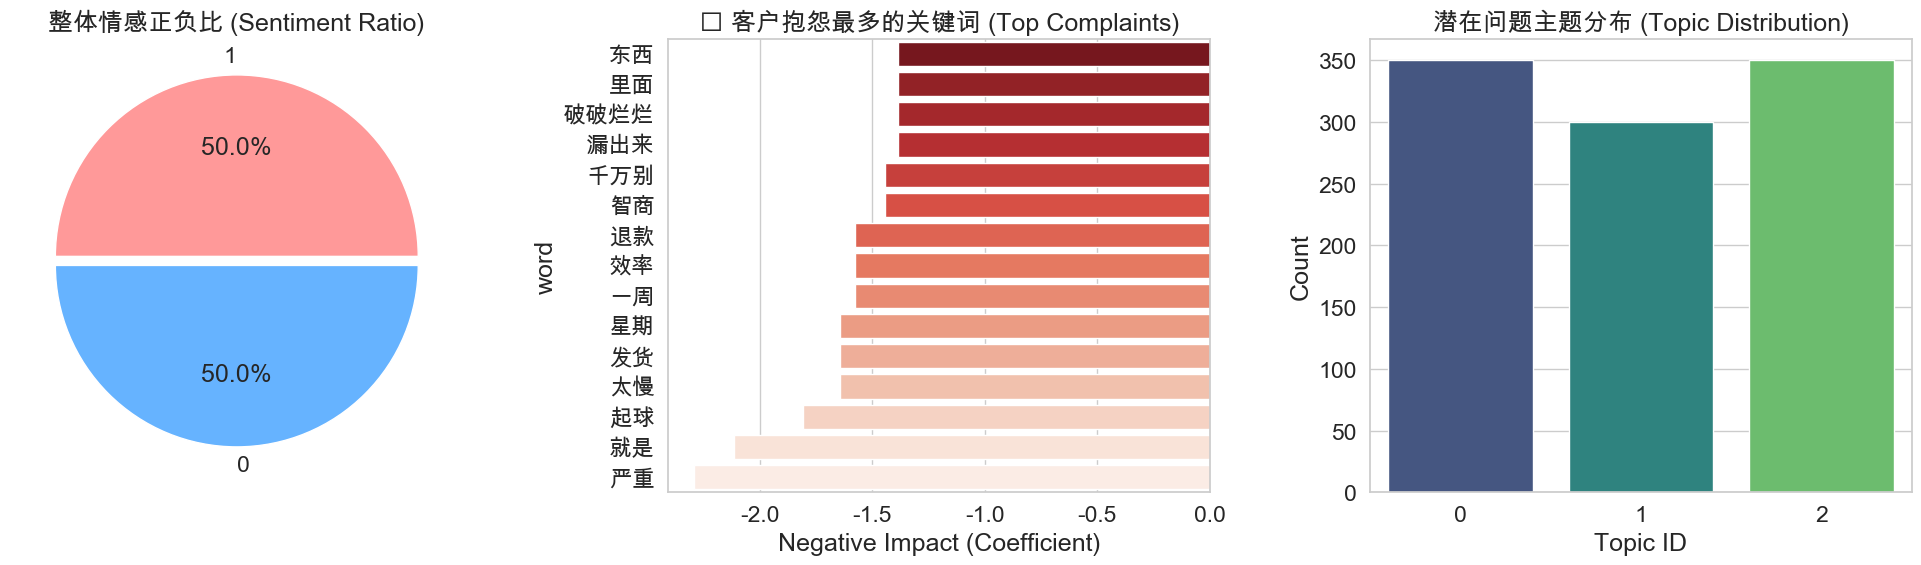

💡 Business Insight Summary:

1. 整体满意度 50%，需警惕。
2. 核心槽点集中在 '物流'(慢/发货) 和 '服务'(不耐烦/推诿)。
3. Topic 2 的投诉量最大，建议优先优化。


In [ ]:
# 8. 商业汇报 Dashboard (Business Insights) 📊
# 场景：老板不看代码，只看图。我们需要把模型结果翻译成 "Actionable Insights"。

plt.figure(figsize=(20, 6))

# 8.1 情感分布饼图 (Sentiment Distribution)
plt.subplot(1, 3, 1)
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('整体情感正负比 (Sentiment Ratio)')
plt.ylabel('')

# 8.2 Top 负面关键词词云/条形图 (Top Negative Keywords)
# 使用逻辑回归系数最负的15个词
plt.subplot(1, 3, 2)
top_negative_words = feature_importance.tail(15)
sns.barplot(x='weight', y='word', data=top_negative_words, palette='Reds_r')
plt.title('客户抱怨最多的关键词 (Top Complaints)')
plt.xlabel('Negative Impact (Coefficient)')

# 8.3 LDA 主题分布 (Topic Distribution)
plt.subplot(1, 3, 3)
sns.countplot(x='topic', data=df, palette='viridis')
plt.title('潜在问题主题分布 (Topic Distribution)')
plt.xlabel('Topic ID')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("💡 Business Insight Summary:")
print("\n1. 整体满意度 50%，需警惕。\n2. 核心槽点集中在 '物流'(慢/发货) 和 '服务'(不耐烦/推诿)。\n3. Topic 2 的投诉量最大，建议优先优化。")